# Binary Face/Non-Face Classification - Educational Analysis

This notebook implements a comprehensive binary face/non-face classification system using multiple machine learning approaches for educational purposes. The implementation includes:

- **HOG feature extraction** for robust image representation
- **Type-1 Logistic Regression** (discriminative approach)
- **Type-2 Gaussian Bayes** (generative approach with shared & separate covariance)
- **Mixture-of-Gaussians (GMM)** (EM-based clustering approach)
- **Extensive visualizations** for understanding each method
- **ROC/AUC analysis** for performance comparison

All visualizations are automatically saved to organized folders for easy review and analysis.

## 1. Configuration and Imports

First, we import all necessary libraries and set up configuration constants for our experiment. This includes:
- **Computer Vision libraries**: OpenCV, scikit-image for image processing
- **Machine Learning libraries**: scikit-learn for classifiers and metrics
- **Visualization libraries**: matplotlib, seaborn for plotting
- **Scientific computing**: numpy for numerical operations

In [1]:
#!/usr/bin/env python
# coding: utf-8
# ---------------------------------------------------------------------
#  Binary Face/Non-Face classification – combined "best of both worlds"
#  • HOG feature extraction
#  • Type-1 Logistic Regression   (discriminative)
#  • Type-2 Gaussian Bayes        (generative, shared & separate Σ)
#  • Mixture-of-Gaussians (GMM)   (optional, EM)
#  • ROC / AUC visualisation
# ---------------------------------------------------------------------

import pathlib, random, itertools, warnings
import numpy as np
import cv2
from skimage import transform, feature, color
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import os

# ------------------------------ 0. CONFIG ------------------------------------
RANDOM_STATE        = 42
IMAGE_SIZE          = (64, 64)            # size after resize for HOG
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_ORIENTATIONS    = 9

FACE_DIR     = pathlib.Path("faces")
NONFACE_DIR  = pathlib.Path("non_faces")
N_PER_CLASS  = 1_000                       # exactly as in exercise
N_TRAIN_PER_CLASS = 800
N_TEST_PER_CLASS  = 200

GMM_COMPONENTS     = 5                     # per class
GMM_COVARIANCE     = "diag"               # faster & better-conditioned

# Results directory configuration
RESULTS_DIR = "results"

## 2. Utility Functions for Plot Saving

We define helper functions for automatically saving all visualizations to organized directories. This ensures all educational plots are preserved for later review and analysis. Plots are saved in both PNG (high resolution) and PDF (vector) formats.

In [2]:
# ------------------------------------------------------------------------------
# 0.1 Save Plot Utility
# ------------------------------------------------------------------------------

def save_plot(fig, filename, subfolder="general"):
    """Save plot to results/subfolder/filename in both PNG and PDF formats."""
    save_dir = os.path.join(RESULTS_DIR, subfolder)
    os.makedirs(save_dir, exist_ok=True)
    
    # Save as PNG and PDF
    png_path = os.path.join(save_dir, f"{filename}.png")
    pdf_path = os.path.join(save_dir, f"{filename}.pdf")
    
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print(f"Saved plot: {png_path} and {pdf_path}")

## 3. Image Loading and HOG Feature Extraction

Here we define the core functions for image processing and feature extraction:

- **`load_and_preprocess()`**: Loads images, converts to grayscale, resizes to standard size, and normalizes to [0,1]
- **`hog_descriptor()`**: Extracts Histogram of Oriented Gradients (HOG) features from preprocessed images

HOG features capture local edge and shape information, making them highly effective for object detection and classification tasks.

In [3]:
# ------------------------------------------------------------------------------
# 1. I/O utilities
# ------------------------------------------------------------------------------

def load_and_preprocess(path: pathlib.Path) -> np.ndarray:
    """Read image → gray → resize → float32 [0,1]."""
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise RuntimeError(f"Cannot read {path}")
    img = cv2.resize(img, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    return img.astype("float32") / 255.0

def hog_descriptor(img: np.ndarray) -> np.ndarray:
    """Return HOG vector for one image."""
    return feature.hog(
        img,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        feature_vector=True
    )

## 4. Dataset Assembly and Visualization

The `assemble_dataset()` function loads exactly 1,000 face and 1,000 non-face images, extracts HOG features, and provides comprehensive visualizations:

1. **Sample Images**: Visual overview of face vs non-face examples
2. **HOG Visualization**: Shows original images, HOG feature images, and feature vectors
3. **Feature Distribution Analysis**: Statistical analysis of HOG feature characteristics

This section helps understand the data and feature extraction process before training classifiers.

In [4]:
def assemble_dataset() -> tuple[np.ndarray, np.ndarray]:
    """Load exactly 1 000 faces + 1 000 non-faces, return (X, y)."""
    face_paths    = sorted(FACE_DIR.glob("*"))[:N_PER_CLASS]
    nonface_paths = sorted(NONFACE_DIR.glob("*"))[:N_PER_CLASS]
    assert len(face_paths) == len(nonface_paths) == N_PER_CLASS, \
        "Need at least 1 000 images per class."

    all_paths  = face_paths + nonface_paths
    all_labels = np.array([1]*N_PER_CLASS + [0]*N_PER_CLASS, dtype=np.int8)

    # Sample visualization
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    for i in range(5):
        face_img = load_and_preprocess(face_paths[i])
        nonface_img = load_and_preprocess(nonface_paths[i])
        axes[0, i].imshow(face_img, cmap='gray')
        axes[0, i].set_title(f'Face {i+1}')
        axes[0, i].axis('off')
        axes[1, i].imshow(nonface_img, cmap='gray')
        axes[1, i].set_title(f'Non-Face {i+1}')
        axes[1, i].axis('off')
    plt.suptitle('Sample Images from Dataset')
    plt.tight_layout()
    save_plot(fig, "01_sample_images", "general")
    plt.show()

    # HOG visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    sample_face = load_and_preprocess(face_paths[0])
    sample_nonface = load_and_preprocess(nonface_paths[0])
    
    hog_face, hog_img_face = feature.hog(sample_face, orientations=HOG_ORIENTATIONS,
                                        pixels_per_cell=HOG_PIXELS_PER_CELL,
                                        cells_per_block=HOG_CELLS_PER_BLOCK,
                                        visualize=True, feature_vector=True)
    hog_nonface, hog_img_nonface = feature.hog(sample_nonface, orientations=HOG_ORIENTATIONS,
                                              pixels_per_cell=HOG_PIXELS_PER_CELL,
                                              cells_per_block=HOG_CELLS_PER_BLOCK,
                                              visualize=True, feature_vector=True)
    
    axes[0, 0].imshow(sample_face, cmap='gray')
    axes[0, 0].set_title('Original Face')
    axes[0, 0].axis('off')
    axes[0, 1].imshow(hog_img_face, cmap='gray')
    axes[0, 1].set_title('HOG Face')
    axes[0, 1].axis('off')
    axes[0, 2].plot(hog_face[:100])
    axes[0, 2].set_title('HOG Features (first 100)')
    axes[0, 2].grid(True)
    
    axes[1, 0].imshow(sample_nonface, cmap='gray')
    axes[1, 0].set_title('Original Non-Face')
    axes[1, 0].axis('off')
    axes[1, 1].imshow(hog_img_nonface, cmap='gray')
    axes[1, 1].set_title('HOG Non-Face')
    axes[1, 1].axis('off')
    axes[1, 2].plot(hog_nonface[:100])
    axes[1, 2].set_title('HOG Features (first 100)')
    axes[1, 2].grid(True)
    
    plt.suptitle('HOG Feature Extraction Visualization')
    plt.tight_layout()
    save_plot(fig, "02_hog_extraction", "general")
    plt.show()

    print("Extracting HOG features …")
    X = np.vstack([hog_descriptor(load_and_preprocess(p)) for p in all_paths])
    
    # Feature distribution analysis
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Feature statistics
    X_face = X[:N_PER_CLASS]
    X_nonface = X[N_PER_CLASS:]
    
    axes[0].hist(X_face.mean(axis=1), bins=30, alpha=0.7, label='Face', color='blue')
    axes[0].hist(X_nonface.mean(axis=1), bins=30, alpha=0.7, label='Non-Face', color='red')
    axes[0].set_title('Mean HOG Feature Values')
    axes[0].set_xlabel('Mean Feature Value')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].hist(X_face.std(axis=1), bins=30, alpha=0.7, label='Face', color='blue')
    axes[1].hist(X_nonface.std(axis=1), bins=30, alpha=0.7, label='Non-Face', color='red')
    axes[1].set_title('HOG Feature Variance')
    axes[1].set_xlabel('Standard Deviation')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()
    axes[1].grid(True)
    
    feature_means_face = X_face.mean(axis=0)
    feature_means_nonface = X_nonface.mean(axis=0)
    feature_diff = feature_means_face - feature_means_nonface
    
    axes[2].plot(feature_diff)
    axes[2].set_title('Feature Discriminability (Face - Non-Face)')
    axes[2].set_xlabel('Feature Index')
    axes[2].set_ylabel('Mean Difference')
    axes[2].grid(True)
    
    plt.tight_layout()
    save_plot(fig, "03_feature_distribution", "general")
    plt.show()
    
    return X, all_labels

## 5. Dataset Splitting and Visualization

The `exact_split()` function creates a stratified train/test split with exact class counts:
- **Training set**: 800 samples per class (1,600 total)
- **Test set**: 200 samples per class (400 total)

This ensures balanced evaluation and reproducible results across all classifier comparisons.

In [5]:
# ------------------------------------------------------------------------------
# 2. Split 800 / 200 per class  (stratified but exact counts)
# ------------------------------------------------------------------------------

def exact_split(X, y):
    idx_face     = np.where(y == 1)[0]
    idx_nonface  = np.where(y == 0)[0]

    rng = random.Random(RANDOM_STATE)
    tr_face  = rng.sample(list(idx_face),    N_TRAIN_PER_CLASS)
    tr_non   = rng.sample(list(idx_nonface), N_TRAIN_PER_CLASS)
    te_face  = list(set(idx_face)    - set(tr_face))
    te_non   = list(set(idx_nonface) - set(tr_non))

    train_idx = tr_face + tr_non
    test_idx  = te_face + te_non

    # Dataset split visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    split_data = ['Train Face', 'Train Non-Face', 'Test Face', 'Test Non-Face']
    split_counts = [len(tr_face), len(tr_non), len(te_face), len(te_non)]
    colors = ['lightblue', 'lightcoral', 'darkblue', 'darkred']
    
    ax1.bar(split_data, split_counts, color=colors)
    ax1.set_title('Dataset Split Distribution')
    ax1.set_ylabel('Number of Samples')
    for i, v in enumerate(split_counts):
        ax1.text(i, v + 10, str(v), ha='center', va='bottom')
    
    ax2.pie(split_counts, labels=split_data, colors=colors, autopct='%1.1f%%')
    ax2.set_title('Dataset Split Proportions')
    
    plt.tight_layout()
    save_plot(fig, "dataset_split", "general")
    plt.show()

    return (X[train_idx], y[train_idx]), (X[test_idx], y[test_idx])

## 6. Logistic Regression Classifier

**Type-1 Logistic Regression** is a discriminative classifier that learns decision boundaries directly. It models the probability P(y|x) using the logistic function and optimizes model parameters through maximum likelihood estimation.

Key characteristics:
- **Discriminative approach**: Models P(class|features) directly
- **Linear decision boundary**: In feature space (but can be non-linear in original space)
- **Probabilistic output**: Provides confidence scores for predictions

In [6]:
# ------------------------------------------------------------------------------
# 3-A. Type-1  Logistic Regression
# ------------------------------------------------------------------------------

def train_logistic(X_tr, y_tr):
    scaler = StandardScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr)
    clf = LogisticRegression(
        max_iter=1_000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ).fit(X_tr_s, y_tr)
    return clf, scaler

## 7. Gaussian Bayes Classifier (Shared and Separate Covariance)

**Type-2 Gaussian Bayes** classifiers are generative models that learn the underlying data distribution for each class. We implement two variants:

1. **Shared Covariance (LDA)**: Assumes both classes have the same covariance matrix
   - Simpler model with fewer parameters
   - Linear decision boundary
   - More robust with limited data

2. **Separate Covariance (QDA)**: Each class has its own covariance matrix
   - More flexible model
   - Quadratic decision boundary
   - Can capture class-specific variance patterns

In [7]:
# ------------------------------------------------------------------------------
# 3-B. Type-2  Gaussian Bayes   (shared & separate Σ)
# ------------------------------------------------------------------------------

def fit_gaussian_params(X_tr, y_tr, shared_cov: bool):
    """Return dict{c: (μ, Σ)} and pooled Σ if shared_cov=True."""
    classes = np.unique(y_tr)
    params  = {}
    for c in classes:
        Xc = X_tr[y_tr == c]
        mu = Xc.mean(0)
        cov = np.cov(Xc, rowvar=False) + 1e-6*np.eye(X_tr.shape[1])
        params[c] = (mu, cov)
    if shared_cov:
        # pooled Σ (average of class covariances, weighted by n-1)
        n0, n1 = sum(y_tr==0), sum(y_tr==1)
        cov_pool = ((n0-1)*params[0][1] + (n1-1)*params[1][1]) / (n0+n1-2)
        params[0] = (params[0][0], cov_pool)
        params[1] = (params[1][0], cov_pool)
    return params

def gaussian_log_likelihood(x, mu, cov):
    """log p(x|μ,Σ) for multivariate Gaussian (allow singular)."""
    from scipy.linalg import cho_factor, cho_solve, LinAlgError
    d = len(mu)
    try:
        c, lower = cho_factor(cov, lower=True, check_finite=False)
        diff = x - mu
        sol  = cho_solve((c, lower), diff.T, check_finite=False)
        quad = np.einsum("ij,ij->j", diff.T, sol)
        logdet = 2.0 * np.sum(np.log(np.diag(c)))
    except LinAlgError:
        # fallback to np.linalg.slogdet (slow) if Cholesky fails
        sign, logdet = np.linalg.slogdet(cov)
        quad = np.einsum("ij,ij->j", diff.T,
                         np.linalg.solve(cov, diff.T))
    return -0.5*(d*np.log(2*np.pi) + logdet + quad)

def predict_gaussian(params, X_te):
    ll_0 = gaussian_log_likelihood(X_te, *params[0])
    ll_1 = gaussian_log_likelihood(X_te, *params[1])
    return (ll_1 > ll_0).astype(int), ll_1 - ll_0

## 8. Mixture-of-Gaussians Classifier

**Gaussian Mixture Models (GMM)** represent each class as a weighted combination of multiple Gaussian components. This approach can capture:

- **Multi-modal distributions**: Classes with multiple clusters
- **Complex shapes**: Non-elliptical class boundaries
- **Subclass structure**: Different subtypes within each class

The model uses the EM (Expectation-Maximization) algorithm to learn component parameters and mixing weights.

In [8]:
# ------------------------------------------------------------------------------
# 3-C. Mixture-of-Gaussians  (optional)
# ------------------------------------------------------------------------------

def fit_gmms(X_tr, y_tr, k=GMM_COMPONENTS, cov_type=GMM_COVARIANCE):
    models = {}
    for c in np.unique(y_tr):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            gmm = GaussianMixture(
                n_components=k,
                covariance_type=cov_type,
                max_iter=200,
                random_state=RANDOM_STATE
            ).fit(X_tr[y_tr == c])
        models[c] = gmm
    return models

def predict_gmm(models, X_te):
    ll_0 = models[0].score_samples(X_te)
    ll_1 = models[1].score_samples(X_te)
    return (ll_1 > ll_0).astype(int), ll_1 - ll_0

## 9. Reporting and Visualization Helpers

These functions provide comprehensive performance analysis and visualization:

- **`report()`**: Generates detailed classification reports with confusion matrices and performance metrics
- **`plot_roc()`**: Creates ROC curves, AUC comparison, score distributions, and precision-recall curves

The visualizations help understand model behavior, compare different approaches, and identify strengths/weaknesses of each classifier.

In [9]:
# ------------------------------------------------------------------------------
# 4.  Pretty printing helpers
# ------------------------------------------------------------------------------

def report(name, y_true, y_pred):
    print(f"\n{name}\n" + "-"*len(name))
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("Confusion matrix (rows=true, cols=pred):")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print(classification_report(y_true, y_pred,
                                target_names=["non-face","face"],
                                digits=4))
    
    # Enhanced confusion matrix visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Face', 'Face'],
                yticklabels=['Non-Face', 'Face'], ax=ax1)
    ax1.set_title(f'{name}\nConfusion Matrix')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    
    # Normalized confusion matrix
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Reds',
                xticklabels=['Non-Face', 'Face'],
                yticklabels=['Non-Face', 'Face'], ax=ax2)
    ax2.set_title(f'{name}\nNormalized Confusion Matrix')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    
    plt.tight_layout()
    save_plot(fig, f"confusion_matrix_{name.replace(' ', '_').replace('(', '').replace(')', '').replace('Σ', 'sigma').lower()}", subfolder=name.split()[0].lower() if name.split()[0] != "Mixture-of-Gaussians" else "gmm")
    plt.show()
    
    # Performance metrics visualization
    tn, fp, fn, tp = cm.ravel()
    metrics = {
        'Accuracy': (tp + tn) / (tp + tn + fp + fn),
        'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'Recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'F1-Score': 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    }
    
    fig2, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(metrics.keys(), metrics.values(), 
                  color=['skyblue', 'lightgreen', 'orange', 'pink', 'lightcoral'])
    ax.set_title(f'{name} - Performance Metrics')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.1)
    
    for bar, value in zip(bars, metrics.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.4f}', ha='center', va='bottom')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    save_plot(fig2, f"metrics_{name.replace(' ', '_').replace('(', '').replace(')', '').replace('Σ', 'sigma').lower()}", subfolder=name.split()[0].lower() if name.split()[0] != "Mixture-of-Gaussians" else "gmm")
    plt.show()

In [10]:
def plot_roc(scores_dict, y_true):
    fig = plt.figure(figsize=(10, 8))
    
    # Main ROC plot
    plt.subplot(2, 2, 1)
    for label, score in scores_dict.items():
        fpr, tpr, _ = roc_curve(y_true, score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{label} (AUC={roc_auc:.3f})")
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves Comparison")
    plt.legend()
    plt.grid(True)
    
    # AUC comparison bar chart
    plt.subplot(2, 2, 2)
    aucs = []
    labels = []
    for label, score in scores_dict.items():
        fpr, tpr, _ = roc_curve(y_true, score)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        labels.append(label)
    
    bars = plt.bar(range(len(aucs)), aucs, color=['blue', 'green', 'red', 'orange'])
    plt.xticks(range(len(aucs)), labels, rotation=45, ha='right')
    plt.ylabel('AUC Score')
    plt.title('AUC Comparison')
    plt.ylim(0, 1.1)
    
    for bar, auc_val in zip(bars, aucs):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{auc_val:.3f}', ha='center', va='bottom')
    
    # Score distributions
    plt.subplot(2, 2, 3)
    for i, (label, score) in enumerate(scores_dict.items()):
        face_scores = score[y_true == 1]
        nonface_scores = score[y_true == 0]
        
        plt.hist(nonface_scores, bins=30, alpha=0.5, label=f'{label} Non-Face', 
                color=f'C{i}', density=True, histtype='step', linestyle='--')
        plt.hist(face_scores, bins=30, alpha=0.5, label=f'{label} Face',
                color=f'C{i}', density=True, histtype='step')
        
    plt.xlabel('Prediction Score')
    plt.ylabel('Density')
    plt.title('Score Distributions')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Precision-Recall curves
    plt.subplot(2, 2, 4)
    from sklearn.metrics import precision_recall_curve, average_precision_score
    
    for label, score in scores_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, score)
        avg_precision = average_precision_score(y_true, score)
        plt.plot(recall, precision, lw=2, 
                label=f"{label} (AP={avg_precision:.3f})")
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    save_plot(fig, "roc_analysis", "general")
    plt.show()

## 10. Main Pipeline: Training, Evaluation, and Visualization

This section orchestrates the complete machine learning pipeline:

1. **Data Loading & Feature Extraction**: Load images and extract HOG features
2. **Dataset Splitting**: Create balanced train/test splits
3. **Dimensionality Reduction**: PCA analysis for visualization and understanding
4. **Model Training**: Train all four classifier types
5. **Model Evaluation**: Test each classifier and generate performance reports
6. **Comparative Analysis**: Compare all methods using ROC curves and other metrics

The pipeline includes extensive visualizations for each step, providing educational insights into the classification process.

Saved plot: results/general/01_sample_images.png and results/general/01_sample_images.pdf


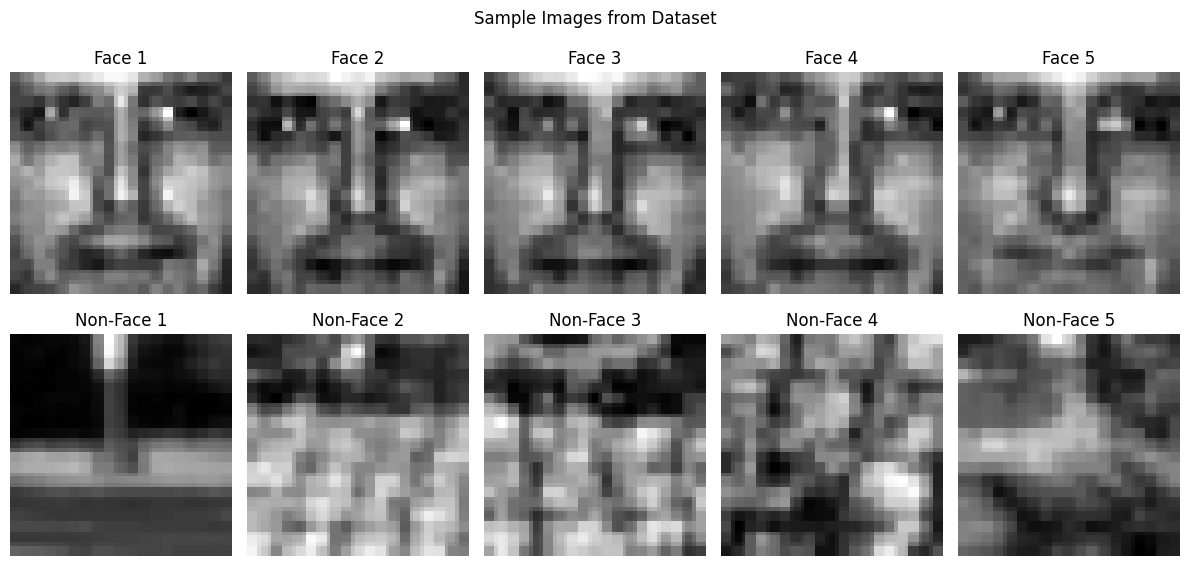

Saved plot: results/general/02_hog_extraction.png and results/general/02_hog_extraction.pdf


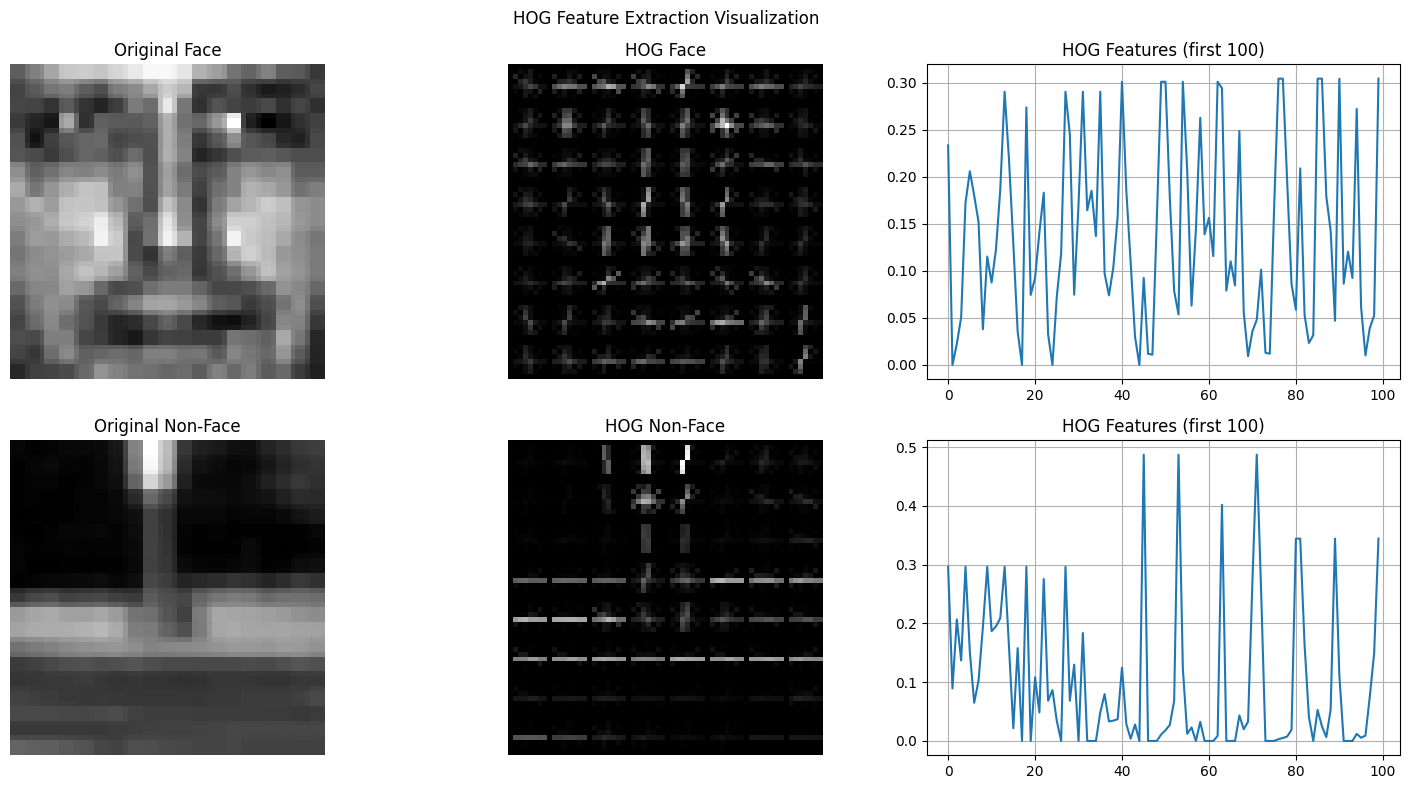

Extracting HOG features …
Saved plot: results/general/03_feature_distribution.png and results/general/03_feature_distribution.pdf


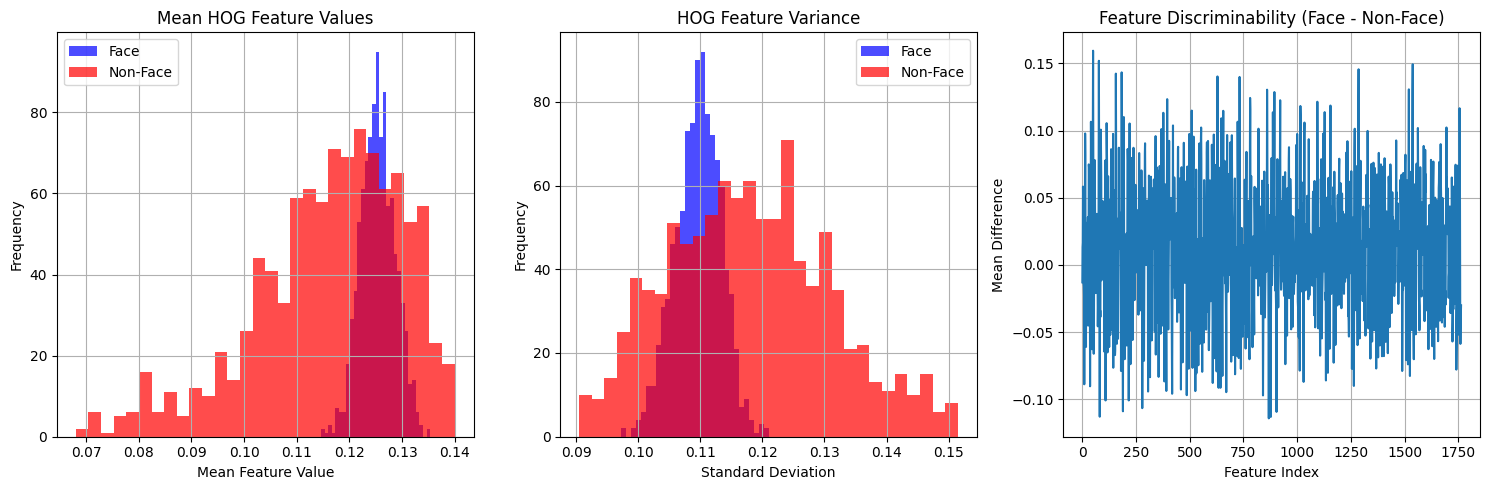

Saved plot: results/general/dataset_split.png and results/general/dataset_split.pdf


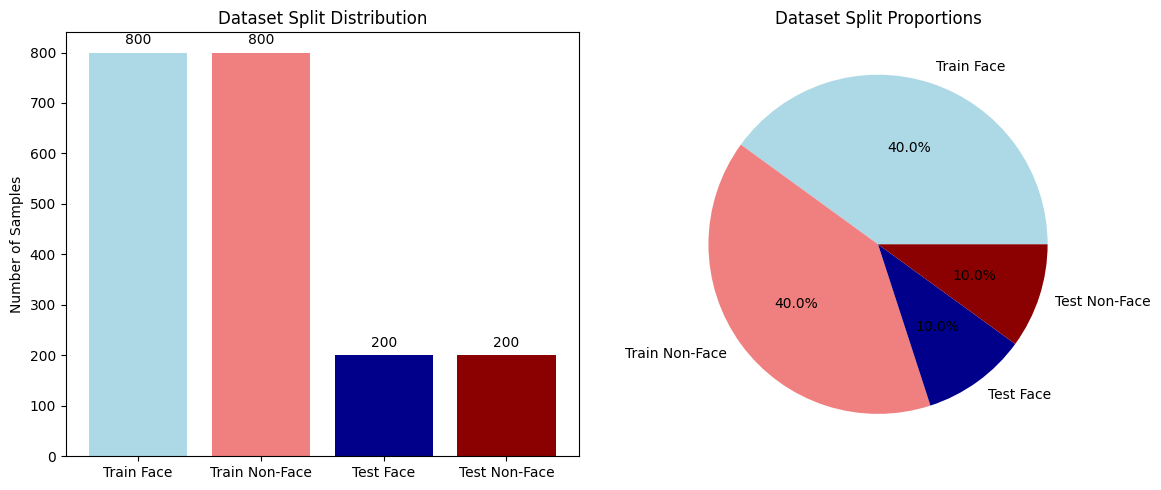

Train: (1600, 1764), Test: (400, 1764)
Performing dimensionality reduction for visualization...
Saved plot: results/general/pca_analysis.png and results/general/pca_analysis.pdf


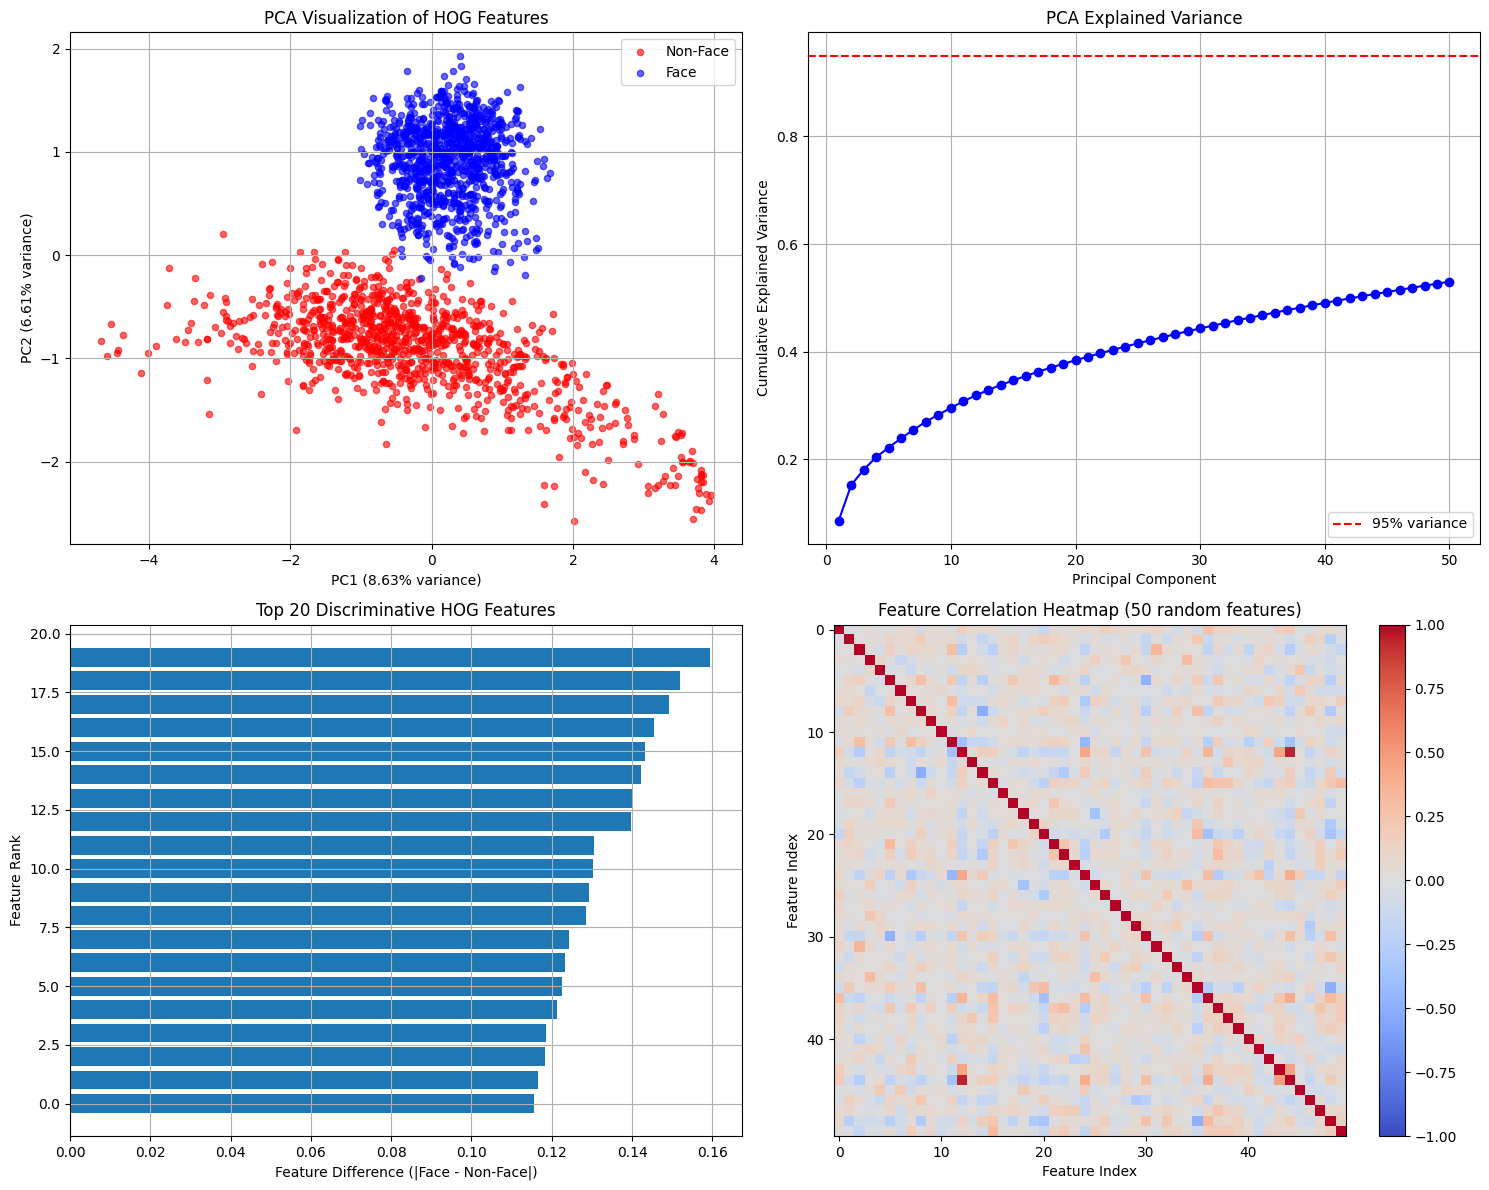

In [11]:
# ------------------------------------------------------------------------------
# 5.  Main Pipeline - Data Loading and Preparation
# ------------------------------------------------------------------------------

# Load dataset and extract features
X, y = assemble_dataset()
(X_tr, y_tr), (X_te, y_te) = exact_split(X, y)
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

# Dimensionality reduction for visualization
print("Performing dimensionality reduction for visualization...")
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# PCA visualization
face_idx = y == 1
nonface_idx = y == 0

ax1.scatter(X_pca[nonface_idx, 0], X_pca[nonface_idx, 1], 
           c='red', alpha=0.6, label='Non-Face', s=20)
ax1.scatter(X_pca[face_idx, 0], X_pca[face_idx, 1], 
           c='blue', alpha=0.6, label='Face', s=20)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax1.set_title('PCA Visualization of HOG Features')
ax1.legend()
ax1.grid(True)

# PCA explained variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

ax2.plot(range(1, min(51, len(cumsum_var)+1)), cumsum_var[:50], 'bo-')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('PCA Explained Variance')
ax2.grid(True)
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
ax2.legend()

# Feature importance (top discriminative features)
X_face_mean = X[face_idx].mean(axis=0)
X_nonface_mean = X[nonface_idx].mean(axis=0)
feature_diff = np.abs(X_face_mean - X_nonface_mean)
top_features = np.argsort(feature_diff)[-20:]

ax3.barh(range(20), feature_diff[top_features])
ax3.set_xlabel('Feature Difference (|Face - Non-Face|)')
ax3.set_ylabel('Feature Rank')
ax3.set_title('Top 20 Discriminative HOG Features')
ax3.grid(True)

# Feature correlation heatmap (subset)
sample_features = np.random.choice(X.shape[1], 50, replace=False)
corr_matrix = np.corrcoef(X[:, sample_features].T)
im = ax4.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax4.set_title('Feature Correlation Heatmap (50 random features)')
ax4.set_xlabel('Feature Index')
ax4.set_ylabel('Feature Index')
plt.colorbar(im, ax=ax4)

plt.tight_layout()
save_plot(fig, "pca_analysis", "general")
plt.show()

Saved plot: results/logistic/logistic_analysis.png and results/logistic/logistic_analysis.pdf


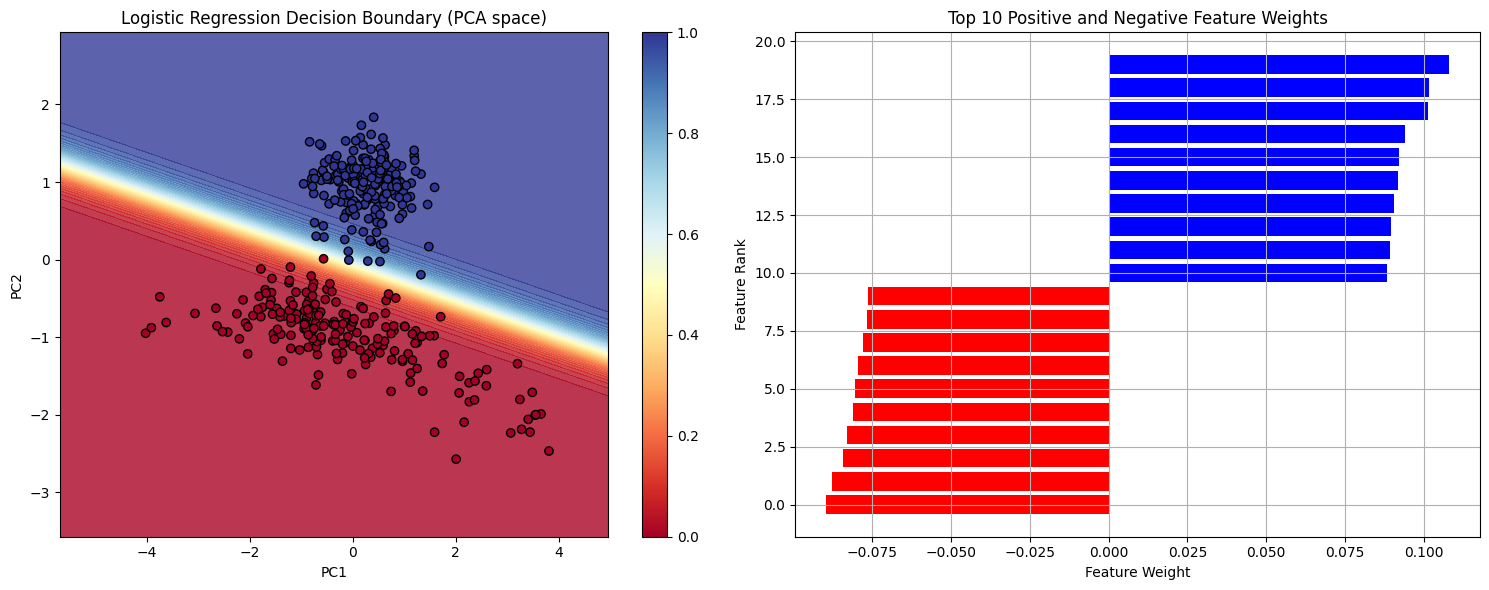


Type-1  Logistic Regression
---------------------------
Accuracy: 1.0000
Confusion matrix (rows=true, cols=pred):
[[200   0]
 [  0 200]]
              precision    recall  f1-score   support

    non-face     1.0000    1.0000    1.0000       200
        face     1.0000    1.0000    1.0000       200

    accuracy                         1.0000       400
   macro avg     1.0000    1.0000    1.0000       400
weighted avg     1.0000    1.0000    1.0000       400

Saved plot: results/type-1/confusion_matrix_type-1__logistic_regression.png and results/type-1/confusion_matrix_type-1__logistic_regression.pdf


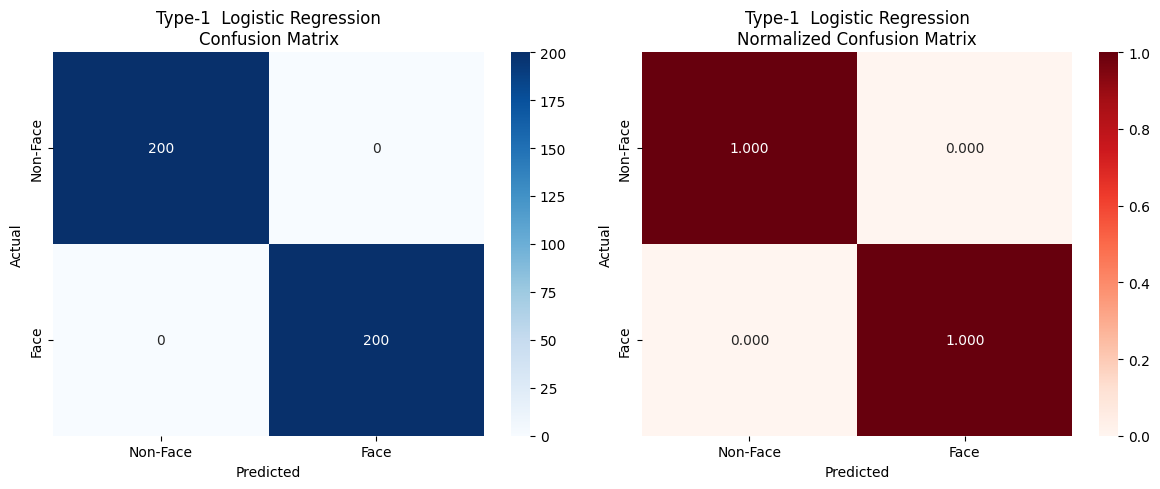

Saved plot: results/type-1/metrics_type-1__logistic_regression.png and results/type-1/metrics_type-1__logistic_regression.pdf


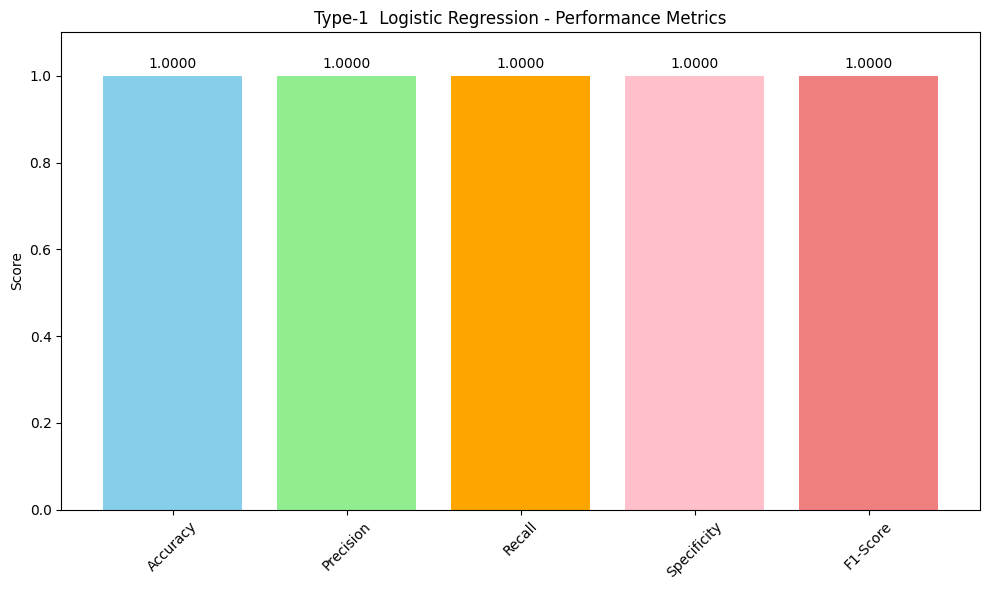

In [12]:
# ------------------------------------------------------------------------------
# Logistic Regression Training and Evaluation
# ------------------------------------------------------------------------------

# Train logistic regression
log_clf, scaler = train_logistic(X_tr, y_tr)
y_pred_log  = log_clf.predict(scaler.transform(X_te))
log_scores  = log_clf.predict_proba(scaler.transform(X_te))[:,1]

# Logistic regression visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Decision boundary in PCA space
X_tr_pca = pca.transform(X_tr)
X_te_pca = pca.transform(X_te)

# Train a simple 2D logistic regression for visualization
from sklearn.linear_model import LogisticRegression as LR_2D
clf_2d = LR_2D(random_state=RANDOM_STATE)
clf_2d.fit(X_tr_pca, y_tr)

h = 0.02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = clf_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

ax1.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu, levels=50)
scatter = ax1.scatter(X_te_pca[:, 0], X_te_pca[:, 1], c=y_te, 
                     cmap=plt.cm.RdYlBu, edgecolors='black')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('Logistic Regression Decision Boundary (PCA space)')
plt.colorbar(scatter, ax=ax1)

# Feature weights
feature_weights = log_clf.coef_[0]
top_pos_weights = np.argsort(feature_weights)[-10:]
top_neg_weights = np.argsort(feature_weights)[:10]

weights_to_plot = np.concatenate([feature_weights[top_neg_weights], 
                                 feature_weights[top_pos_weights]])
labels_to_plot = list(range(len(top_neg_weights))) + list(range(len(top_pos_weights)))
colors = ['red'] * len(top_neg_weights) + ['blue'] * len(top_pos_weights)

ax2.barh(range(len(weights_to_plot)), weights_to_plot, color=colors)
ax2.set_xlabel('Feature Weight')
ax2.set_ylabel('Feature Rank')
ax2.set_title('Top 10 Positive and Negative Feature Weights')
ax2.grid(True)

plt.tight_layout()
save_plot(fig, "logistic_analysis", "logistic")
plt.show()

report("Type-1  Logistic Regression", y_te, y_pred_log)

Saved plot: results/gaussian_shared/gaussian_shared_analysis.png and results/gaussian_shared/gaussian_shared_analysis.pdf


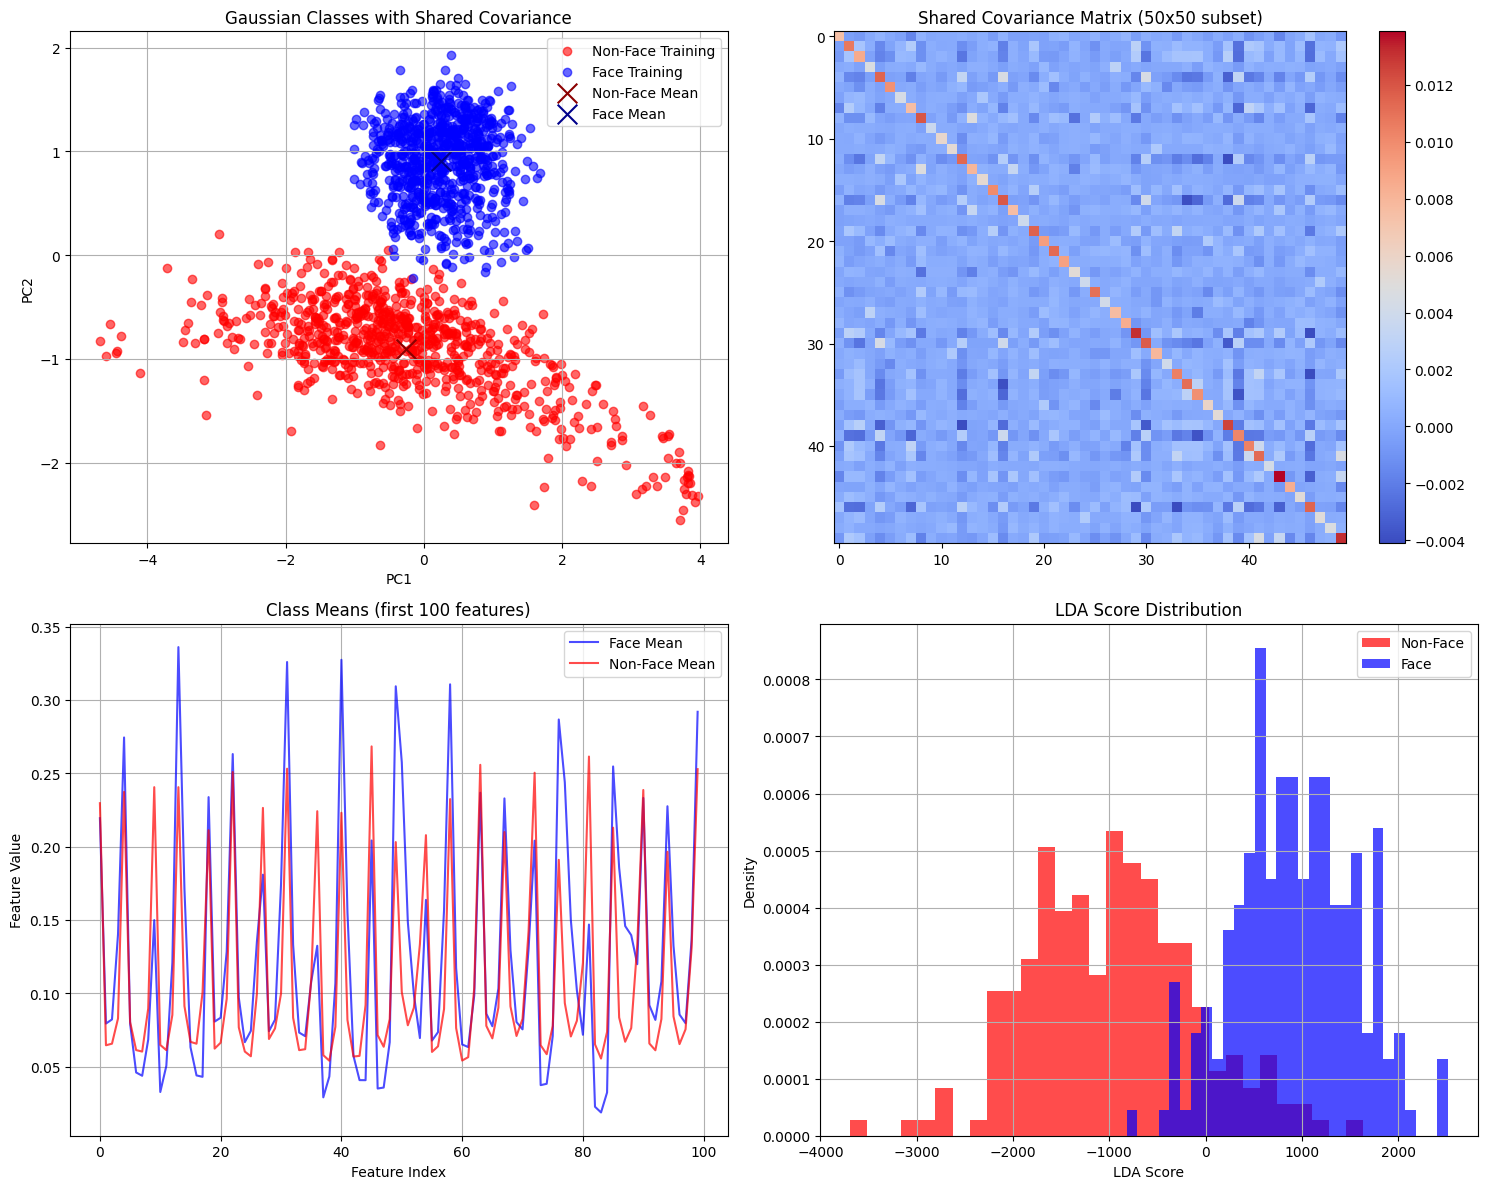


Type-2  Gaussian Bayes  (shared Σ)
----------------------------------
Accuracy: 0.9025
Confusion matrix (rows=true, cols=pred):
[[175  25]
 [ 14 186]]
              precision    recall  f1-score   support

    non-face     0.9259    0.8750    0.8997       200
        face     0.8815    0.9300    0.9051       200

    accuracy                         0.9025       400
   macro avg     0.9037    0.9025    0.9024       400
weighted avg     0.9037    0.9025    0.9024       400

Saved plot: results/type-2/confusion_matrix_type-2__gaussian_bayes__shared_sigma.png and results/type-2/confusion_matrix_type-2__gaussian_bayes__shared_sigma.pdf


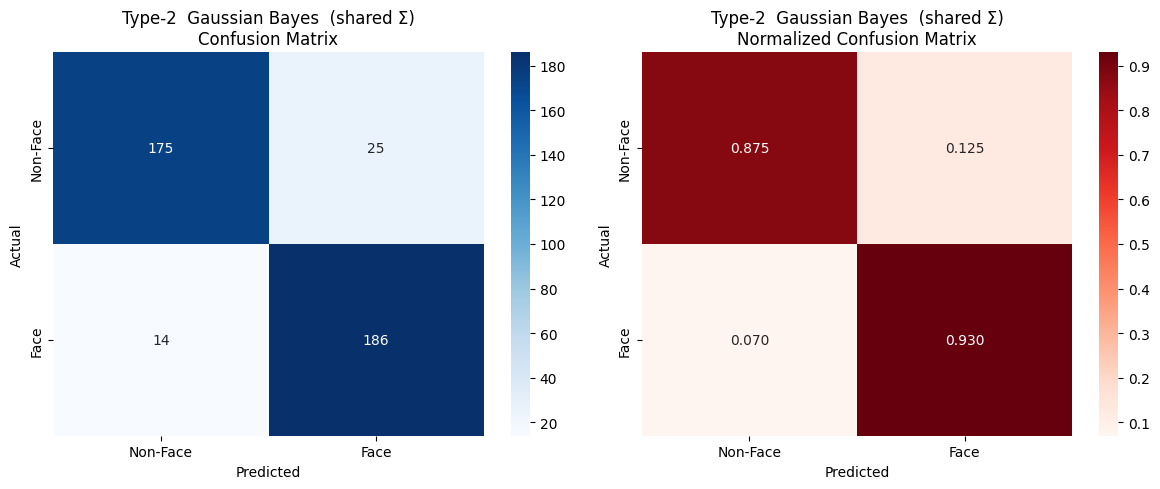

Saved plot: results/type-2/metrics_type-2__gaussian_bayes__shared_sigma.png and results/type-2/metrics_type-2__gaussian_bayes__shared_sigma.pdf


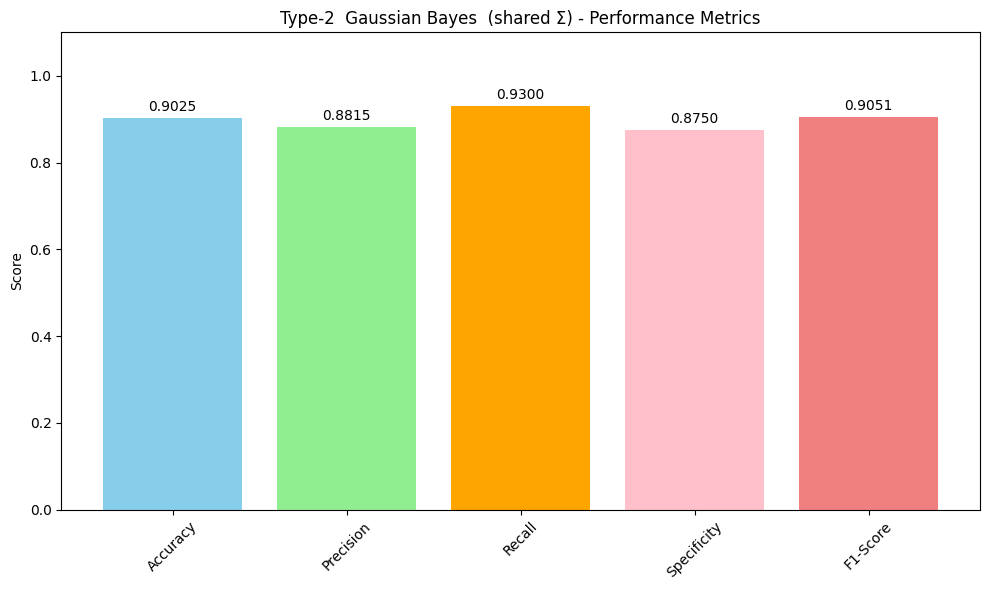

In [13]:
# ------------------------------------------------------------------------------
# Gaussian Bayes (Shared Covariance) Training and Evaluation
# ------------------------------------------------------------------------------

# Train Gaussian Bayes with shared covariance (LDA)
params_shared = fit_gaussian_params(X_tr, y_tr, shared_cov=True)
y_pred_lda, lda_scores = predict_gaussian(params_shared, X_te)

# Gaussian visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Class means in PCA space
X_tr_face_pca = X_tr_pca[y_tr == 1]
X_tr_nonface_pca = X_tr_pca[y_tr == 0]

axes[0, 0].scatter(X_tr_nonface_pca[:, 0], X_tr_nonface_pca[:, 1], 
                  c='red', alpha=0.6, label='Non-Face Training')
axes[0, 0].scatter(X_tr_face_pca[:, 0], X_tr_face_pca[:, 1], 
                  c='blue', alpha=0.6, label='Face Training')

# Plot class means
mean_face_pca = X_tr_face_pca.mean(axis=0)
mean_nonface_pca = X_tr_nonface_pca.mean(axis=0)
axes[0, 0].scatter(mean_nonface_pca[0], mean_nonface_pca[1], 
                  c='darkred', s=200, marker='x', label='Non-Face Mean')
axes[0, 0].scatter(mean_face_pca[0], mean_face_pca[1], 
                  c='darkblue', s=200, marker='x', label='Face Mean')

axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')
axes[0, 0].set_title('Gaussian Classes with Shared Covariance')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Covariance visualization
cov_face = params_shared[1][1]
cov_nonface = params_shared[0][1]

# Show covariance as heatmap (subset)
subset_idx = np.random.choice(cov_face.shape[0], 50, replace=False)
cov_subset = cov_face[np.ix_(subset_idx, subset_idx)]

im1 = axes[0, 1].imshow(cov_subset, cmap='coolwarm')
axes[0, 1].set_title('Shared Covariance Matrix (50x50 subset)')
plt.colorbar(im1, ax=axes[0, 1])

# Feature means comparison
mean_face = params_shared[1][0]
mean_nonface = params_shared[0][0]

axes[1, 0].plot(mean_face[:100], 'b-', label='Face Mean', alpha=0.7)
axes[1, 0].plot(mean_nonface[:100], 'r-', label='Non-Face Mean', alpha=0.7)
axes[1, 0].set_xlabel('Feature Index')
axes[1, 0].set_ylabel('Feature Value')
axes[1, 0].set_title('Class Means (first 100 features)')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Score distribution
axes[1, 1].hist(lda_scores[y_te == 0], bins=30, alpha=0.7, 
               label='Non-Face', color='red', density=True)
axes[1, 1].hist(lda_scores[y_te == 1], bins=30, alpha=0.7, 
               label='Face', color='blue', density=True)
axes[1, 1].set_xlabel('LDA Score')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('LDA Score Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
save_plot(fig, "gaussian_shared_analysis", "gaussian_shared")
plt.show()

report("Type-2  Gaussian Bayes  (shared Σ)", y_te, y_pred_lda)

Saved plot: results/gaussian_separate/gaussian_separate_analysis.png and results/gaussian_separate/gaussian_separate_analysis.pdf


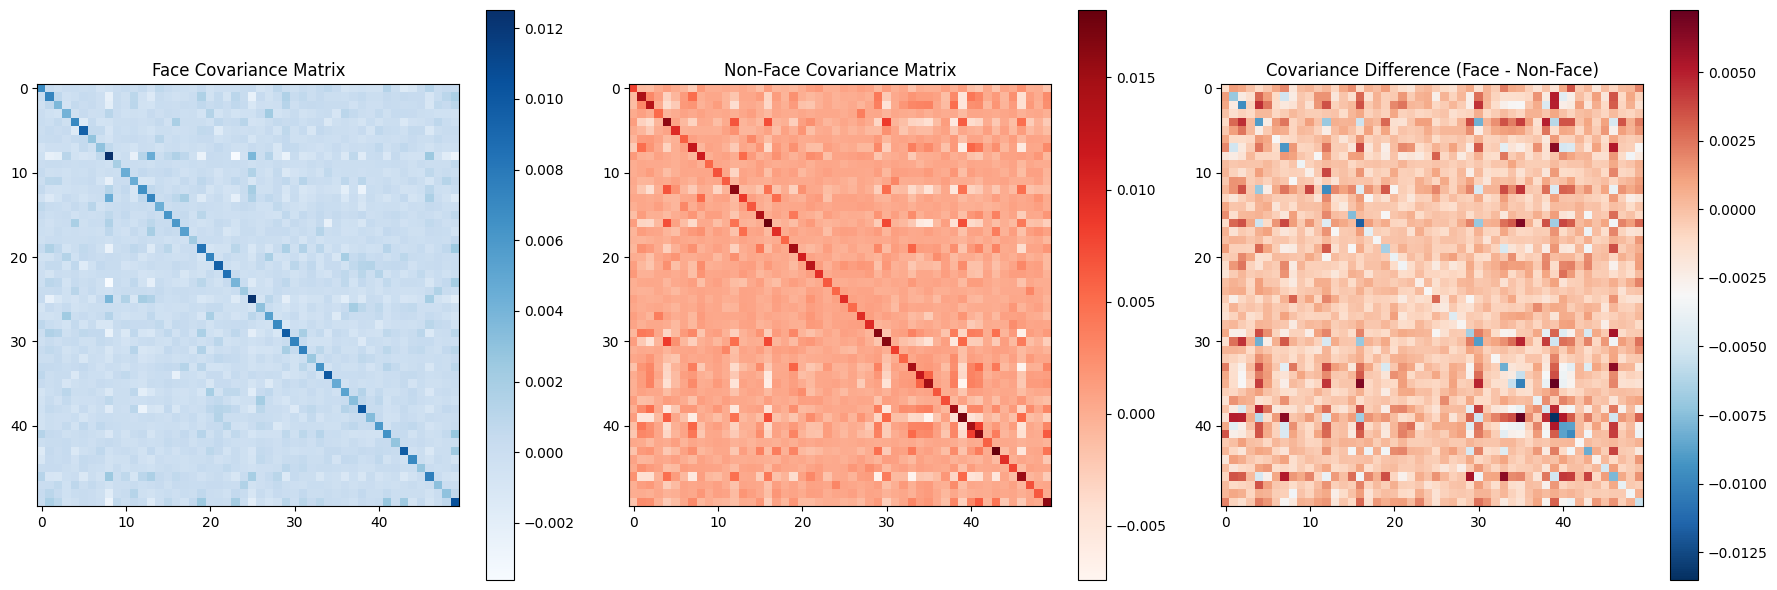


Type-2  Gaussian Bayes  (separate Σ)
------------------------------------
Accuracy: 0.9825
Confusion matrix (rows=true, cols=pred):
[[193   7]
 [  0 200]]
              precision    recall  f1-score   support

    non-face     1.0000    0.9650    0.9822       200
        face     0.9662    1.0000    0.9828       200

    accuracy                         0.9825       400
   macro avg     0.9831    0.9825    0.9825       400
weighted avg     0.9831    0.9825    0.9825       400

Saved plot: results/type-2/confusion_matrix_type-2__gaussian_bayes__separate_sigma.png and results/type-2/confusion_matrix_type-2__gaussian_bayes__separate_sigma.pdf


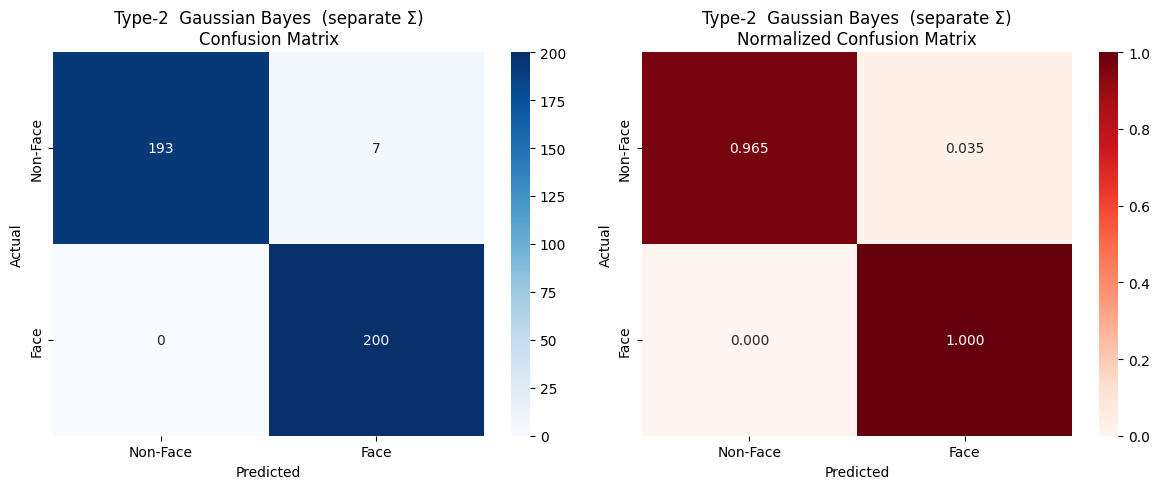

Saved plot: results/type-2/metrics_type-2__gaussian_bayes__separate_sigma.png and results/type-2/metrics_type-2__gaussian_bayes__separate_sigma.pdf


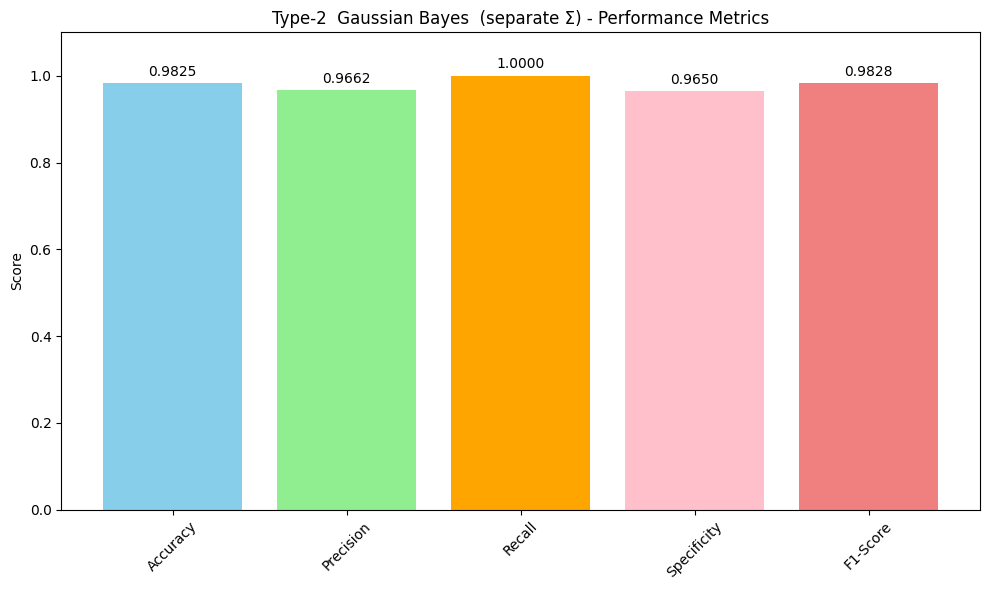

Saved plot: results/gmm/gmm_analysis.png and results/gmm/gmm_analysis.pdf


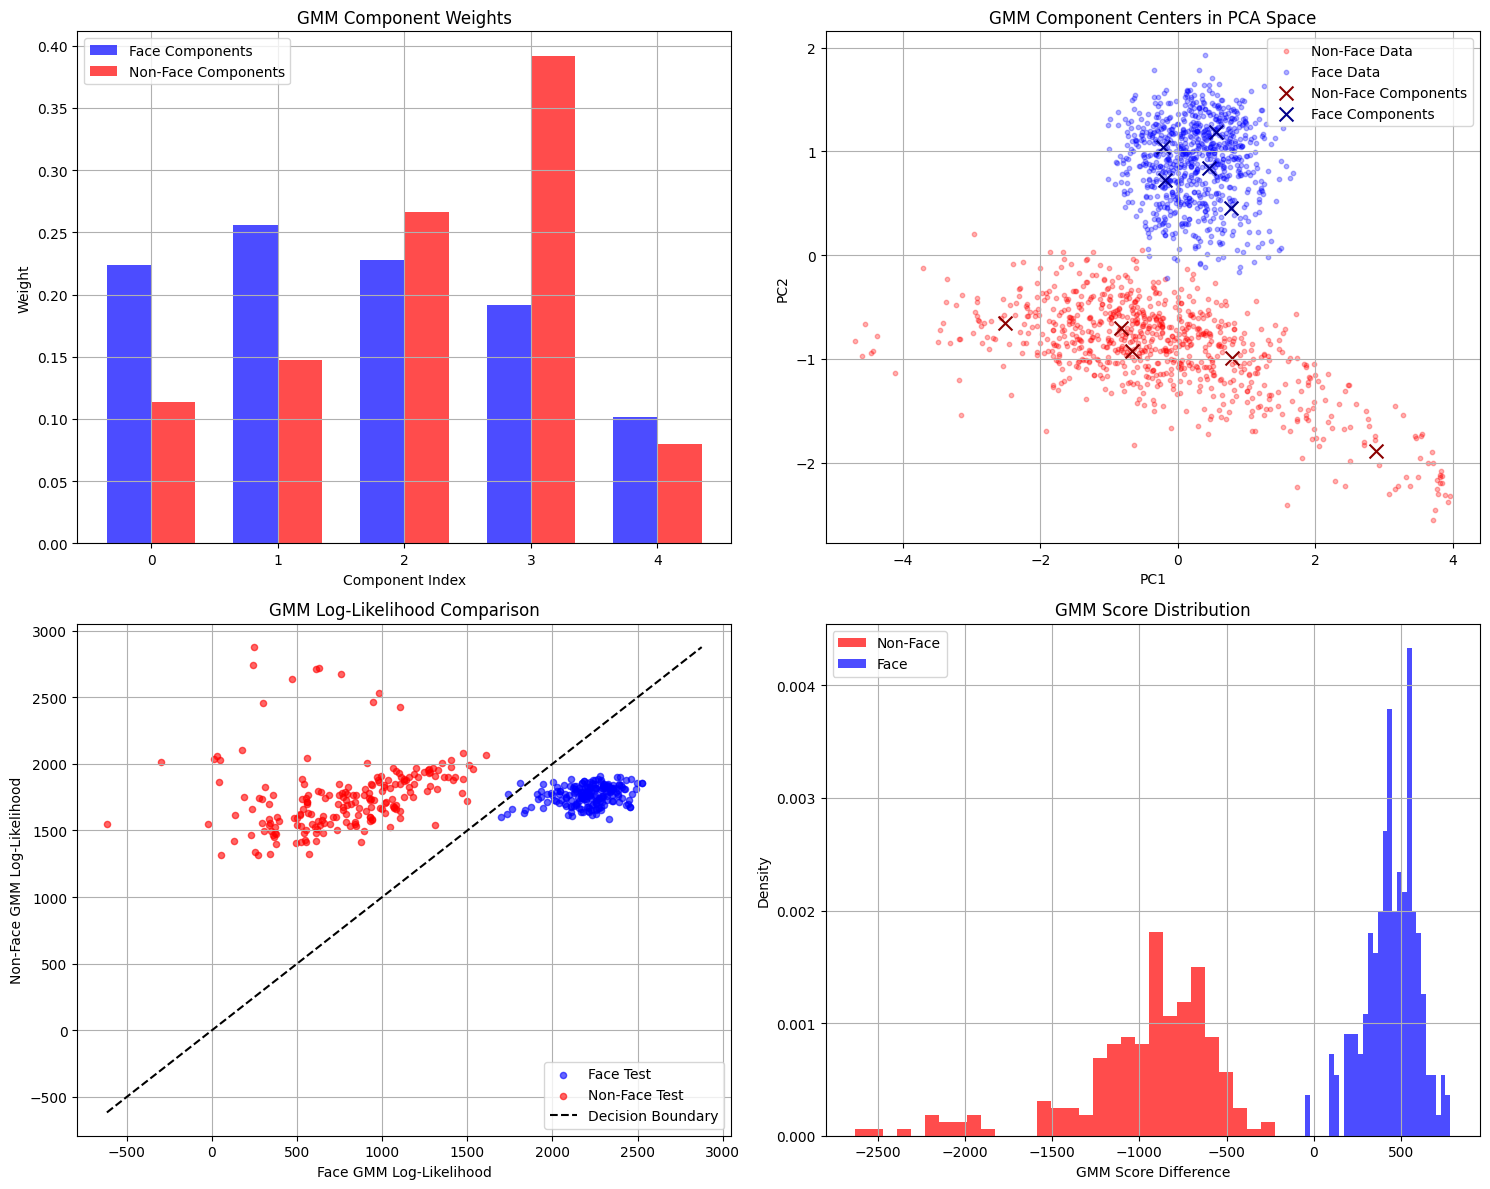


Mixture-of-Gaussians  (5×diag)
------------------------------
Accuracy: 0.9950
Confusion matrix (rows=true, cols=pred):
[[200   0]
 [  2 198]]
              precision    recall  f1-score   support

    non-face     0.9901    1.0000    0.9950       200
        face     1.0000    0.9900    0.9950       200

    accuracy                         0.9950       400
   macro avg     0.9950    0.9950    0.9950       400
weighted avg     0.9950    0.9950    0.9950       400

Saved plot: results/gmm/confusion_matrix_mixture-of-gaussians__5×diag.png and results/gmm/confusion_matrix_mixture-of-gaussians__5×diag.pdf


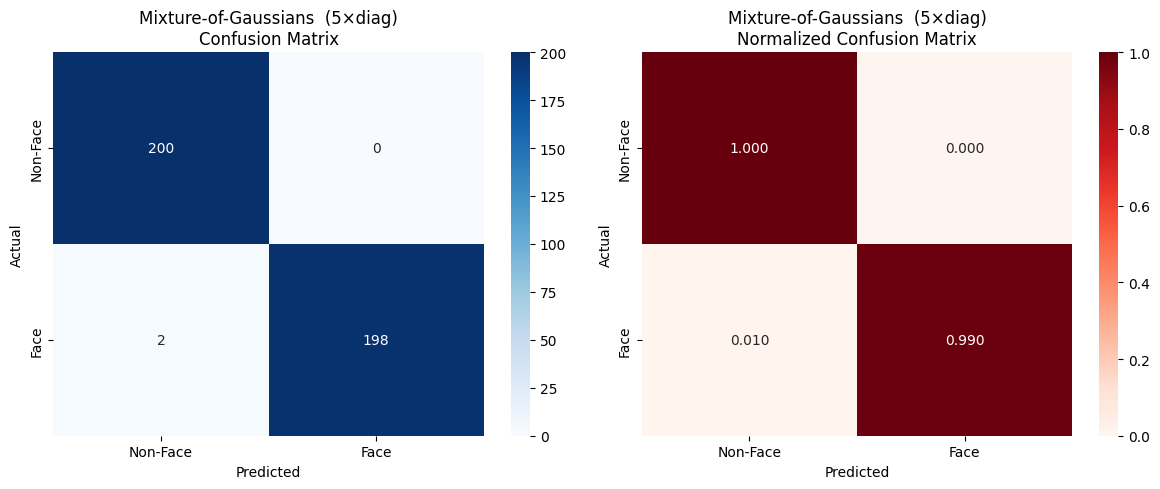

Saved plot: results/gmm/metrics_mixture-of-gaussians__5×diag.png and results/gmm/metrics_mixture-of-gaussians__5×diag.pdf


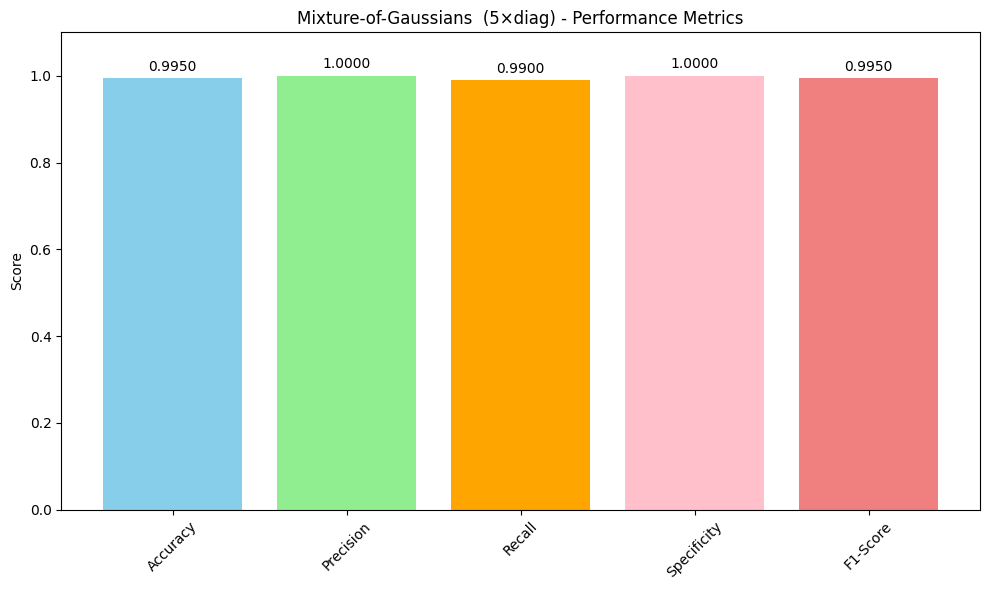

In [14]:
# ------------------------------------------------------------------------------
# Gaussian Bayes (Separate Covariance) Training and Evaluation
# ------------------------------------------------------------------------------

# Train Gaussian Bayes with separate covariance (QDA)
params_sep = fit_gaussian_params(X_tr, y_tr, shared_cov=False)
y_pred_nb, nb_scores = predict_gaussian(params_sep, X_te)

# Separate covariance visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cov_face_sep = params_sep[1][1]
cov_nonface_sep = params_sep[0][1]

# Face covariance
cov_face_subset = cov_face_sep[np.ix_(subset_idx, subset_idx)]
im1 = axes[0].imshow(cov_face_subset, cmap='Blues')
axes[0].set_title('Face Covariance Matrix')
plt.colorbar(im1, ax=axes[0])

# Non-face covariance  
cov_nonface_subset = cov_nonface_sep[np.ix_(subset_idx, subset_idx)]
im2 = axes[1].imshow(cov_nonface_subset, cmap='Reds')
axes[1].set_title('Non-Face Covariance Matrix')
plt.colorbar(im2, ax=axes[1])

# Covariance difference
cov_diff = cov_face_subset - cov_nonface_subset
im3 = axes[2].imshow(cov_diff, cmap='RdBu_r')
axes[2].set_title('Covariance Difference (Face - Non-Face)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
save_plot(fig, "gaussian_separate_analysis", "gaussian_separate")
plt.show()

report("Type-2  Gaussian Bayes  (separate Σ)", y_te, y_pred_nb)

# ------------------------------------------------------------------------------
# Mixture-of-Gaussians Training and Evaluation
# ------------------------------------------------------------------------------

# Train GMM
gmm_models = fit_gmms(X_tr, y_tr)
y_pred_gmm, gmm_scores = predict_gmm(gmm_models, X_te)

# GMM visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Component weights
face_weights = gmm_models[1].weights_
nonface_weights = gmm_models[0].weights_

x = np.arange(GMM_COMPONENTS)
width = 0.35

axes[0, 0].bar(x - width/2, face_weights, width, label='Face Components', color='blue', alpha=0.7)
axes[0, 0].bar(x + width/2, nonface_weights, width, label='Non-Face Components', color='red', alpha=0.7)
axes[0, 0].set_xlabel('Component Index')
axes[0, 0].set_ylabel('Weight')
axes[0, 0].set_title('GMM Component Weights')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Component means in PCA space (if possible)
face_means_pca = pca.transform(gmm_models[1].means_)
nonface_means_pca = pca.transform(gmm_models[0].means_)

axes[0, 1].scatter(X_tr_nonface_pca[:, 0], X_tr_nonface_pca[:, 1], 
                  c='red', alpha=0.3, s=10, label='Non-Face Data')
axes[0, 1].scatter(X_tr_face_pca[:, 0], X_tr_face_pca[:, 1], 
                  c='blue', alpha=0.3, s=10, label='Face Data')

axes[0, 1].scatter(nonface_means_pca[:, 0], nonface_means_pca[:, 1], 
                  c='darkred', s=100, marker='x', label='Non-Face Components')
axes[0, 1].scatter(face_means_pca[:, 0], face_means_pca[:, 1], 
                  c='darkblue', s=100, marker='x', label='Face Components')

axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')
axes[0, 1].set_title('GMM Component Centers in PCA Space')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Log-likelihood comparison
face_ll = gmm_models[1].score_samples(X_te)
nonface_ll = gmm_models[0].score_samples(X_te)

axes[1, 0].scatter(face_ll[y_te == 1], nonface_ll[y_te == 1], 
                  c='blue', alpha=0.6, label='Face Test', s=20)
axes[1, 0].scatter(face_ll[y_te == 0], nonface_ll[y_te == 0], 
                  c='red', alpha=0.6, label='Non-Face Test', s=20)

# Decision boundary line
min_val = min(face_ll.min(), nonface_ll.min())
max_val = max(face_ll.max(), nonface_ll.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'k--', 
               label='Decision Boundary')

axes[1, 0].set_xlabel('Face GMM Log-Likelihood')
axes[1, 0].set_ylabel('Non-Face GMM Log-Likelihood')
axes[1, 0].set_title('GMM Log-Likelihood Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True)

# GMM score distribution
axes[1, 1].hist(gmm_scores[y_te == 0], bins=30, alpha=0.7, 
               label='Non-Face', color='red', density=True)
axes[1, 1].hist(gmm_scores[y_te == 1], bins=30, alpha=0.7, 
               label='Face', color='blue', density=True)
axes[1, 1].set_xlabel('GMM Score Difference')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('GMM Score Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
save_plot(fig, "gmm_analysis", "gmm")
plt.show()

report(f"Mixture-of-Gaussians  ({GMM_COMPONENTS}×{GMM_COVARIANCE})",
       y_te, y_pred_gmm)